### Optimizers in Deep Learning

An **Optimizer** is the mathematical algorithm used to update the internal parameters (weights and biases) of a neural network in order to minimize the Loss Function.

While **Backpropagation** calculates the gradient (the direction and steepness of the error), the **Optimizer** uses those gradients to decide exactly *how large* of a step to take and in *which direction* to actually alter the weights.

---

## 1. Standard SGD (Stochastic Gradient Descent)

**The Analogy:** A blindfolded hiker taking very rigid, fixed-size steps directly down the steepest slope they feel under their foot.

* **How it works:** It simply takes the gradient (slope) calculated by backpropagation, multiplies it by the Learning Rate ($\alpha$), and subtracts it from the current weight.
* **Math:** $W_{new} = W_{old} - \alpha \cdot g$
* **Effects on the Model:**
* **Pros:** Extremely simple. Uses very little memory since it doesn't store past gradients.
* **Cons (The "Ravine" Problem):** If the loss valley looks like a steep, narrow ravine, the gradients on the walls are massive, but the gradient pointing toward the actual bottom is tiny. SGD will violently bounce back and forth across the ravine walls, making incredibly slow progress toward the actual minimum.
* **Cons (Local Minima):** If it hits a small dip in the hill (a local minimum), the gradient becomes `0`, and SGD gets permanently trapped.


* **Key Hyperparameters:**
* `learning_rate` ($\alpha$): The size of the step.



## 2. SGD with Momentum

**The Analogy:** Rolling a heavy bowling ball down a hill.

* **How it works:** Instead of just looking at the current step, Momentum remembers the *past* steps. If the optimizer has been moving in the same direction for a while, it builds up "speed" (velocity).
* **Math:** 1. Update Velocity: $v_{new} = \beta \cdot v_{old} + (1 - \beta) \cdot g$
2. Update Weight: $W_{new} = W_{old} - \alpha \cdot v_{new}$
* **Effects on the Model:**
* **Solves Local Minima:** Because the optimizer builds up speed as it rolls down the hill, if it hits a small ditch (local minimum), it has enough momentum to blast right through it and keep going down the real mountain.
* **Solves Ravines:** The violent left-and-right bounces cancel each other out in the velocity memory, while the small forward steps add up. It dampens the bouncing and accelerates straight down the ravine.


* **Key Hyperparameters:**
* `momentum` ($\beta$): Usually set to `0.9` (meaning it remembers 90% of its previous velocity).



## 3. RMSprop (Root Mean Square Propagation)

**The Analogy:** A hiker wearing adaptive shoes that automatically shrink their steps on steep, dangerous cliffs and widen their steps on flat, safe ground.

* **How it works:** It introduces **Adaptive Learning Rates**. It keeps a running average of the *squared* gradients. If a specific weight has massive gradients (it's bouncing wildly), RMSprop mathematically penalizes it by shrinking its specific learning rate. If a weight has tiny gradients, it boosts its learning rate.
* **Math:** 1. Average of squared gradients: $S = \beta \cdot S + (1 - \beta) \cdot g^2$
2. Update Weight: $W_{new} = W_{old} - \frac{\alpha}{\sqrt{S + \epsilon}} \cdot g$
*(Notice we divide the learning rate by the square root of $S$, scaling the step size down if gradients are huge).*
* **Effects on the Model:**
* **The Great Stabilizer:** It completely eliminates the ravine bouncing problem. Every single weight in the network gets its own custom, continuously updating learning rate.
* Highly effective in Recurrent Neural Networks (RNNs) where gradients tend to explode.



## 4. Adam (Adaptive Moment Estimation)

**The Analogy:** The ultimate hiker. They are a heavy bowling ball (Momentum) wearing adaptive shoes (RMSprop).

* **How it works:** Adam is literally the combination of Momentum and RMSprop. It keeps track of the moving average of the gradients (Momentum / "First Moment") AND the moving average of the squared gradients (RMSprop / "Second Moment").
* **Effects on the Model:**
* **The Industry Standard:** Adam is the default optimizer for 95% of Deep Learning applications. It converges (finds the bottom) drastically faster than standard SGD.
* **Robustness:** It is highly forgiving of poor hyperparameter choices. Even if you pick a slightly bad learning rate, Adam's adaptive math will usually correct it automatically, saving you hours of tuning.


* **Key Hyperparameters:**
* `learning_rate` ($\alpha$): Usually starts at `0.001` (`1e-3`).
* `beta_1`: Controls Momentum (usually `0.9`).
* `beta_2`: Controls RMSprop scaling (usually `0.999`).
* `epsilon` ($\epsilon$): A tiny number (like `1e-7`) to prevent dividing by zero.



## 5. AdamW (Adam with Weight Decay)

**The Analogy:** Adam, but with a mathematically correct diet plan to prevent getting too heavy (Overfitting).

* **How it works:** In standard Adam, adding L2 Regularization (Weight Decay) interacts weirdly with the adaptive learning rates, making the regularization much weaker than intended. AdamW decouples the weight decay math from the gradient math, applying the penalty directly to the weights.
* **Effects on the Model:**
* **The Modern Champion:** For highly advanced, massive models (like Transformers, LLMs, and Vision Transformers), AdamW has completely replaced standard Adam. It yields models that generalize much better to unseen data.



---

### Optimizer Cheatsheet: Which one should you use?

1. **Adam (`tf.keras.optimizers.Adam`)**: Start here. Use this for 90% of your projects (tabular data, basic CNNs, standard MLPs).
2. **AdamW (`tf.keras.optimizers.AdamW`)**: Switch to this if you are building Transformers, Large Language Models, or if your standard Adam model is stubbornly overfitting despite adding Dropout.
3. **SGD + Momentum**: Use this if you are doing highly advanced Computer Vision research. While Adam trains *faster*, a perfectly tuned SGD with Momentum can sometimes find a *slightly* deeper, better minimum on image classification tasks (ResNet, VGG), but it requires extensive trial and error to tune the learning rate scheduler.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

C:\Users\Hp\AppData\Roaming\Python\Python311\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
df = pd.read_csv("Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
X = df[['Age', 'EstimatedSalary']]
y = df[["Purchased"]]
X,y

(     Age  EstimatedSalary
 0     19            19000
 1     35            20000
 2     26            43000
 3     27            57000
 4     19            76000
 ..   ...              ...
 395   46            41000
 396   51            23000
 397   50            20000
 398   36            33000
 399   49            36000
 
 [400 rows x 2 columns],
      Purchased
 0            0
 1            0
 2            0
 3            0
 4            0
 ..         ...
 395          1
 396          1
 397          1
 398          0
 399          1
 
 [400 rows x 1 columns])

In [4]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
def build_model():
    model = Sequential([
        Dense(32, activation='relu', input_shape=(2,)), 
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid') 
    ])
    return model

In [13]:
optimizers = {
    'SGD (Vanilla)': tf.keras.optimizers.SGD(learning_rate=0.01),
    'SGD + Momentum': tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'RMSprop': tf.keras.optimizers.RMSprop(learning_rate=0.01),
    'Adam': tf.keras.optimizers.Adam(learning_rate=0.01)
}

In [14]:
history = {}
epochs = 50

In [16]:
for name, optimizer in optimizers.items():
    print(f"<===Training with {name}===>")
    model = build_model()
    
    model.compile(optimizer=optimizer,loss="binary_crossentropy",metrics=['accuracy'])
    
    record = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_test_scaled, y_test),
        epochs=epochs,
        batch_size=32, 
        verbose=0      
    )
    
    history[name] = record
    _, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
    print(f"Final Test Accuracy: {test_acc:.4f}\n")

<===Training with SGD (Vanilla)===>


C:\Users\Hp\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Final Test Accuracy: 0.9500

<===Training with SGD + Momentum===>


C:\Users\Hp\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Final Test Accuracy: 0.9375

<===Training with RMSprop===>


C:\Users\Hp\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Final Test Accuracy: 0.9375

<===Training with Adam===>


C:\Users\Hp\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Final Test Accuracy: 0.9375



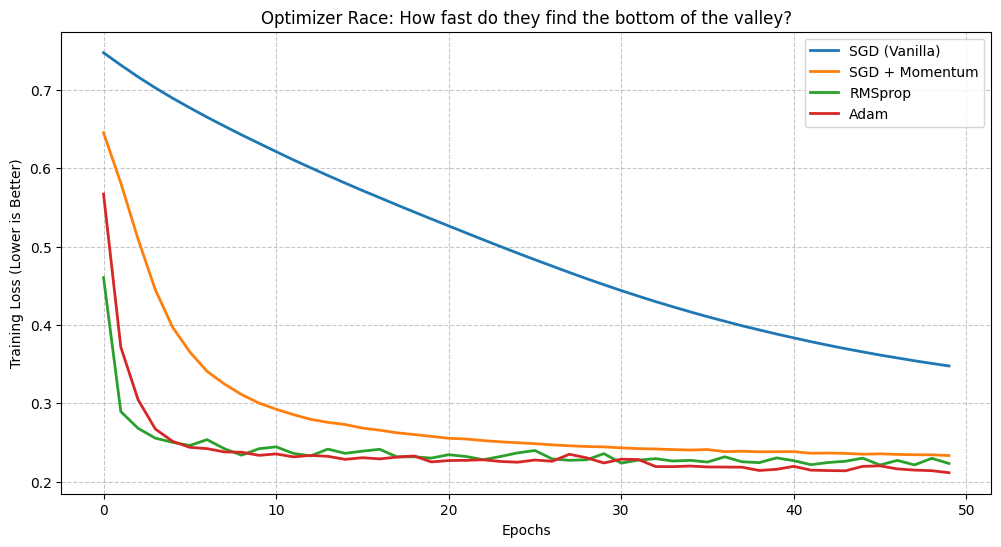

In [17]:
plt.figure(figsize=(12, 6))

for opt_name, history in history.items():
    plt.plot(history.history['loss'], label=opt_name, linewidth=2)

plt.title('Optimizer Race: How fast do they find the bottom of the valley?')
plt.xlabel('Epochs')
plt.ylabel('Training Loss (Lower is Better)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()